# ANALYSIS OF JACOBIAN STATIONARITY

In [1]:
import src.constants as cn
from src.jacobian_collection_maker import JacobianCollectionMaker

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helpers

In [2]:
def plotCluster(n_cluster: int = 1, is_sequential: bool=False):
    if is_sequential:
        sequential1 = "s"
        sequential2 = "_sequential"
    else:
        sequential1 = ""
        sequential2 = ""
    out_file = f"{n_cluster}{sequential1}_model_linearity_analysis_data{sequential2}.csv"
    data_path = os.path.join(cn.DATA_DIR, out_file)
    try:
        data_df = pd.read_csv(data_path, header=None, names=['value'], index_col=0)
    except:
        raise ValueError("No data for {n_cluster} clusters")
    ser = data_df["value"]
    ser = ser.clip(upper = 1)
    _ = plt.hist(ser, bins=100)
    plt.title(f"Total models: {len(ser)}. n_cluster: {n_cluster}, sequential: {is_sequential}")
    plt.xlabel("max coefficient of variation of Jacobian values (clipped at 1)")
    plt.ylim([0, 500])
    _ = plt.ylabel("number models")
    indices = [i for i in ser.index.values if isinstance(i, str)]
    return ser[indices]

# Histograms for non-contiguous clusters

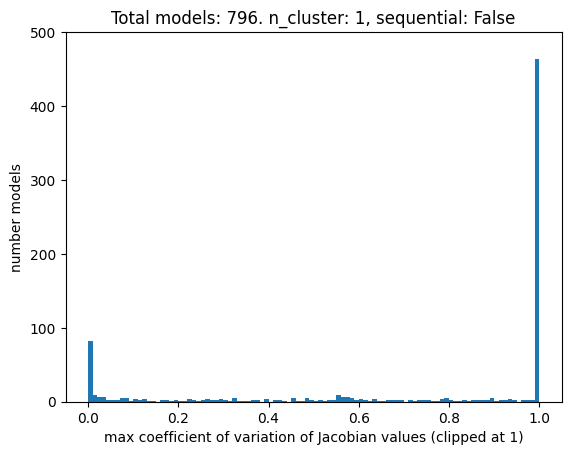

In [3]:
ser1 = plotCluster(n_cluster=1)

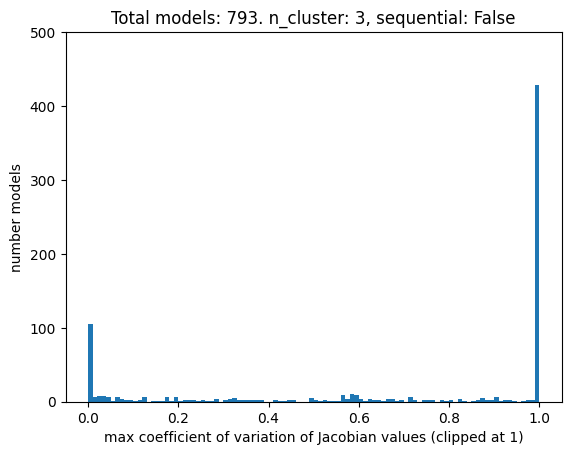

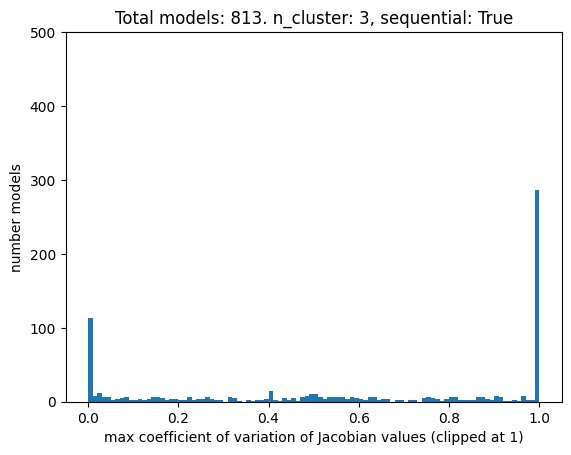

In [4]:
ser = plotCluster(n_cluster=3)
plt.figure()
ser3 = plotCluster(n_cluster=3, is_sequential=True)

In [5]:
idxs = list(set(ser1.index).intersection(ser3.index))
df = pd.DataFrame({"s1": ser1[idxs], "s3": ser3[idxs]})
df = df[ df["s3"] > 0 ]
df["ratio"] = df["s1"] / df["s3"]
df[df["ratio"] > 10]

,s1,s3,ratio
BIOMD0000000038,1.000000e+00,1.597423e-11,6.260084e+10
BIOMD0000000057,1.427424e-07,5.713397e-14,2.498381e+06
BIOMD0000000500,1.008398e-01,6.809121e-04,1.480951e+02
BIOMD0000000126,2.129557e-06,2.584161e-08,8.240806e+01
BIOMD0000000633,1.000000e+00,7.375361e-03,1.355866e+02
BIOMD0000000426,1.626373e-01,2.549434e-03,6.379347e+01
BIOMD0000001080,1.990006e-12,5.743456e-15,3.464823e+02
BIOMD0000000483,1.942890e-15,1.387779e-16,1.400000e+01
BIOMD0000000520,1.000000e+00,1.566460e-11,6.383820e+10
BIOMD0000000668,1.817059e-15,1.817059e-16,1.000000e+01


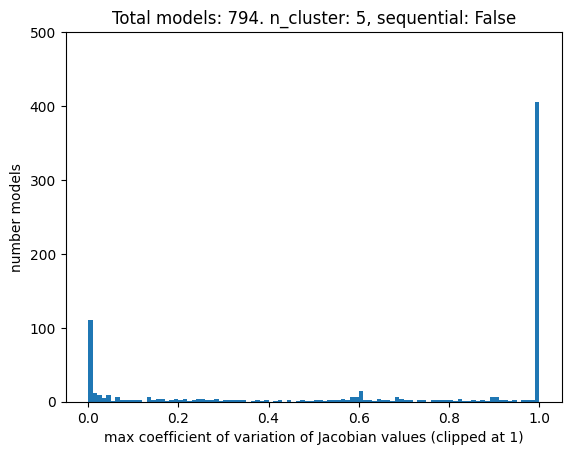

In [6]:
ser = plotCluster(n_cluster=5, is_sequential=False)

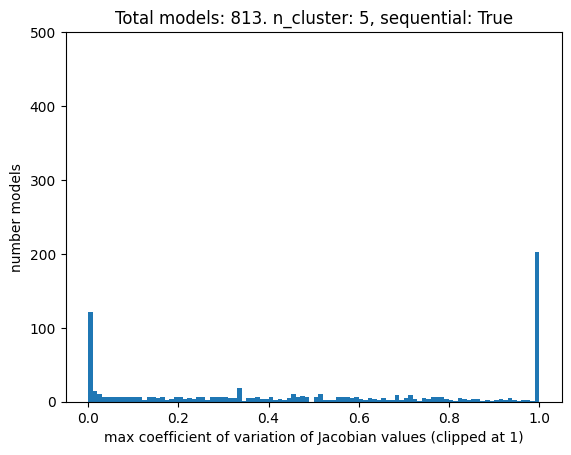

In [7]:
ser = plotCluster(n_cluster=5, is_sequential=True)

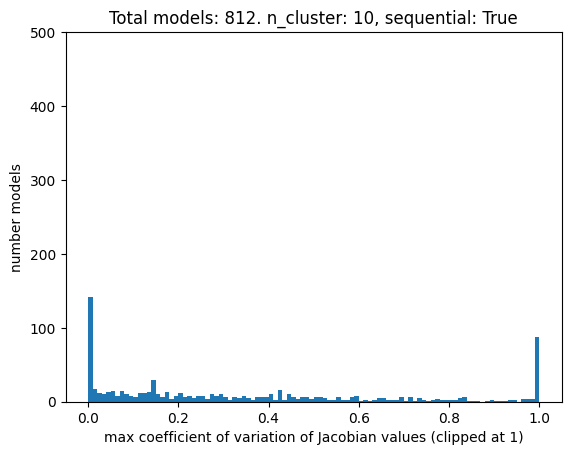

In [8]:
ser = plotCluster(n_cluster=10, is_sequential=True)

# Analysis of 309

In [9]:
ser1.head(50)


BIOMD0000000001    1.076701e-11
BIOMD0000000002    1.000000e+00
BIOMD0000000003    5.686333e-01
BIOMD0000000004    6.665167e-01
BIOMD0000000005    1.000000e+00
BIOMD0000000008    1.000000e+00
BIOMD0000000010    2.441738e-01
BIOMD0000000012    1.000000e+00
BIOMD0000000013    4.293858e-01
BIOMD0000000015    6.895310e-06
BIOMD0000000017    1.000000e+00
BIOMD0000000018    1.364329e-03
BIOMD0000000021    1.000000e+00
BIOMD0000000022    1.000000e+00
BIOMD0000000023    5.552774e-01
BIOMD0000000026    8.764990e-01
BIOMD0000000027    7.933740e-01
BIOMD0000000028    1.000000e+00
BIOMD0000000029    9.697125e-01
BIOMD0000000030    1.000000e+00
BIOMD0000000031    7.590869e-01
BIOMD0000000032    1.000000e+00
BIOMD0000000033    1.000000e+00
BIOMD0000000035    1.000000e+00
BIOMD0000000036    1.000000e+00
BIOMD0000000037    1.000000e+00
BIOMD0000000038    1.000000e+00
BIOMD0000000039    1.000000e+00
BIOMD0000000040    1.000000e+00
BIOMD0000000041    1.000000e+00
BIOMD0000000042    1.000000e+00
BIOMD000

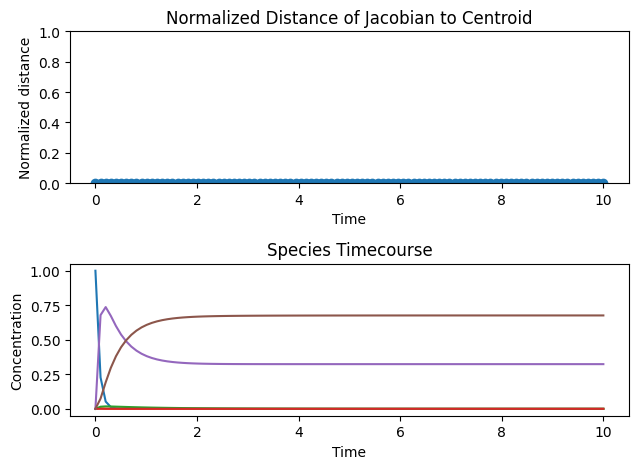

In [13]:
def plotAnalysis(model_num: int, end_time: int, num_point=100, ylim=(0,1)):
    base_str = "BIOMD000000"
    model_name = base_str + f"{model_num:04d}"
    path = os.path.join(
        cn.BIOMODELS_DIR, model_name, f"{model_name}_url.xml"
    )
    with open(path) as f:
        sbml_str = f.read()
        maker = JacobianCollectionMaker(sbml_str, start_time=0.0, end_time=end_time, num_points=num_point)
        collection = maker.makeCollection()
        collection.plot(maker.roadrunner_maker,is_legend=False, ylim=ylim)

# Tests
plotAnalysis(57, 10)

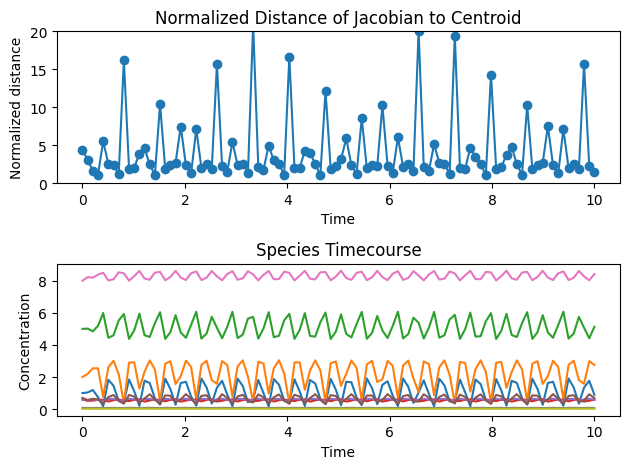

In [15]:
plotAnalysis(206, 10, ylim=(0, 20))